# 🖼️ AI Agent Hub — Agente de Visão (CNN com MobileNetV2)
Este notebook implementa a nova versão do **Agente de Visão**,
substituindo a abordagem heurística por um modelo de **aprendizado profundo leve**.

### ⚙️ Objetivo
Treinar uma **MobileNetV2 pré-treinada (ImageNet)** para classificar imagens de:
- **Porcas**
- **Parafusos**

### 📁 Estrutura esperada do dataset:
/content/data/images/


### 🧠 Saída:
- Modelo salvo em `/content/data/models/vision_cnn.pth`
- Log JSON com métricas e relatório técnico em `/content/data/logs/`

O treino roda **em CPU**, com poucas épocas e camadas descongeladas (rápido e eficiente).


# 🧰 Imports e configuração inicial
Nesta célula:
- Importamos PyTorch e bibliotecas auxiliares.
- Criamos as pastas de logs e modelos.


In [1]:
import os, json, uuid, time
from datetime import datetime
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Pastas principais
os.makedirs("/content/data/models", exist_ok=True)
os.makedirs("/content/data/logs", exist_ok=True)
os.makedirs("/content/data/images", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Usando dispositivo: {device}")


🖥️ Usando dispositivo: cpu


# 📦 Carregamento do dataset
O PyTorch automaticamente lê a estrutura de pastas via `ImageFolder`.
Aplicamos transformações básicas de data augmentation e normalização.

💡 Certifique-se de que o caminho `/content/data/images` contenha as subpastas
'porca/' e 'parafuso/' com imagens dentro.



In [2]:
import os
import shutil
import random
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# caminhos
root_images = "/content/data/images"            # sua pasta original (NÃO será alterada)
dataset_copy_root = "/content/data/images_dataset"  # pasta onde faremos a cópia organizada

# cria pastas de destino (limpa se já existir para evitar arquivos antigos misturados)
if os.path.exists(dataset_copy_root):
    print(f"⚠️ Diretório {dataset_copy_root} já existe — ele será recriado (somente cópias serão sobrescritas).")
    # não removemos suas imagens originais; removemos apenas a pasta de trabalho
    shutil.rmtree(dataset_copy_root)

porca_dir = os.path.join(dataset_copy_root, "porca")
parafuso_dir = os.path.join(dataset_copy_root, "parafuso")
os.makedirs(porca_dir, exist_ok=True)
os.makedirs(parafuso_dir, exist_ok=True)

# lista de arquivos de imagem na pasta raiz (ignora subpastas)
files = [f for f in os.listdir(root_images) if f.lower().endswith((".jpg", ".jpeg", ".png")) and os.path.isfile(os.path.join(root_images, f))]

if not files:
    raise RuntimeError(f"❌ Nenhuma imagem encontrada em {root_images}. Verifique o caminho e os arquivos.")

# padrões para classificar automaticamente
porca_keys = ("porca", "nut")
parafuso_keys = ("parafuso", "parafus", "bolt")  # 'parafus' pega variações como 'parafusos'

undetermined = []

for f in files:
    lower = f.lower()
    src = os.path.join(root_images, f)
    if any(k in lower for k in parafuso_keys):
        dst = os.path.join(parafuso_dir, f)
        shutil.copy2(src, dst)
    elif any(k in lower for k in porca_keys):
        dst = os.path.join(porca_dir, f)
        shutil.copy2(src, dst)
    else:
        undetermined.append(f)

# distribuir os não identificados aleatoriamente entre as duas pastas
random.shuffle(undetermined)
half = len(undetermined) // 2
for f in undetermined[:half]:
    shutil.copy2(os.path.join(root_images, f), os.path.join(porca_dir, f))
for f in undetermined[half:]:
    shutil.copy2(os.path.join(root_images, f), os.path.join(parafuso_dir, f))

# imprime estrutura resultante
print("✅ Cópia organizada criada em:", dataset_copy_root)
for root, dirs, files in os.walk(dataset_copy_root):
    level = root.replace(dataset_copy_root, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

# ---------------------------
# Agora criamos o dataset ImageFolder a partir da cópia
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

data_dir = dataset_copy_root  # apontamos para a cópia organizada (não tocamos nos originais)
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
print("\nClasses detectadas pelo ImageFolder:", class_names)

# split treino/teste
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

print(f"\n✅ Dataset pronto. Total imagens: {len(dataset)} | Treino: {len(train_data)} | Teste: {len(test_data)}")


✅ Cópia organizada criada em: /content/data/images_dataset
images_dataset/
  porca/
    img08.jpg
    img02.jpg
    img10.jpg
    img09.jpg
    img05.jpg
  parafuso/
    img_parafusos_03.jpg
    img_parafusos_02.jpg
    img_parafusos_04.jpg
    img07.jpg
    img_parafusos_05.jpg
    img04.jpg
    img_parafusos_01.jpg
    img01.jpg
    img03.jpg
    img06.jpg

Classes detectadas pelo ImageFolder: ['parafuso', 'porca']

✅ Dataset pronto. Total imagens: 15 | Treino: 12 | Teste: 3


# 🧠 Configuração do modelo MobileNetV2
Nesta célula, carregamos o modelo **MobileNetV2** pré-treinado no **ImageNet** e
substituímos a camada final para duas classes: **porca** e **parafuso**.

⚙️ Estratégia:
- Congelamos as camadas convolucionais (backbone);
- Treinamos apenas o classificador final;
- Rodamos tudo em CPU (leve e rápido).


In [3]:
from torchvision import models, datasets
from torch import nn, optim

# Caminho atualizado do dataset organizado
data_dir = "/content/data/images_dataset"

# Carrega as classes do dataset
dataset = datasets.ImageFolder(root=data_dir)
class_names = dataset.classes
print(f"📂 Classes detectadas automaticamente: {class_names}")

# Carrega modelo pré-treinado
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Congela o backbone (mantém apenas o classificador treinável)
for param in model.features.parameters():
    param.requires_grad = False

# Substitui a camada final (head) para duas classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

# Move modelo para CPU (ou GPU se disponível)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)

print(f"✅ Modelo MobileNetV2 configurado com sucesso para {len(class_names)} classes.")
print(f"🧩 Dispositivo de treino: {device}")

📂 Classes detectadas automaticamente: ['parafuso', 'porca']
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 99.1MB/s]

✅ Modelo MobileNetV2 configurado com sucesso para 2 classes.
🧩 Dispositivo de treino: cpu


# 🔁 Treinamento do modelo (2-3 épocas)
Treinamos apenas a última camada (head) da MobileNetV2.
Rodamos poucas épocas para manter execução rápida em CPU.



In [4]:

from tqdm import tqdm

num_epochs = 3
train_losses, val_losses, val_accuracies = [], [], []

print("🚀 Iniciando treinamento da MobileNetV2...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Época {epoch+1}/{num_epochs}", leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validação
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, 1)
            correct += torch.sum(preds == labels).item()

    acc = correct / len(test_data)
    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(acc)

    print(f"📊 Época [{epoch+1}/{num_epochs}] | Loss Treino: {avg_train_loss:.3f} | Val Loss: {val_loss:.3f} | Acurácia: {acc*100:.2f}%")

print("\n✅ Treinamento concluído!")

🚀 Iniciando treinamento da MobileNetV2...



📊 Época [1/3] | Loss Treino: 0.581 | Val Loss: 0.658 | Acurácia: 66.67%


📊 Época [2/3] | Loss Treino: 0.568 | Val Loss: 0.618 | Acurácia: 66.67%


📊 Época [3/3] | Loss Treino: 0.509 | Val Loss: 0.613 | Acurácia: 66.67%

✅ Treinamento concluído!


# 📊 Avaliação e relatório técnico
Calculamos acurácia final e salvamos o modelo e log de execução.



In [5]:
import numpy as np
import json
import uuid
from datetime import datetime

# Avaliação final
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

accuracy = correct / total
print(f"\n✅ Acurácia final do modelo: {accuracy*100:.2f}%")

# Caminhos
model_path = "/content/data/models/vision_cnn.pth"
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Salva o modelo
torch.save(model.state_dict(), model_path)

# Log JSON
log_data = {
    "agent": "vision_agent_cnn",
    "model": "MobileNetV2",
    "classes": class_names,
    "accuracy": round(accuracy, 3),
    "epochs": num_epochs,
    "train_loss_mean": round(np.mean(train_losses), 3),
    "val_loss_mean": round(np.mean(val_losses), 3),
    "timestamp_utc": datetime.utcnow().isoformat() + "Z"
}

log_path = f"/content/data/logs/vision_agent_cnn_{uuid.uuid4().hex[:8]}.json"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w", encoding="utf-8") as f:
    json.dump(log_data, f, indent=2, ensure_ascii=False)

print(f"📁 Modelo salvo em: {model_path}")
print(f"🧾 Log salvo em: {log_path}")


✅ Acurácia final do modelo: 66.67%
📁 Modelo salvo em: /content/data/models/vision_cnn.pth
🧾 Log salvo em: /content/data/logs/vision_agent_cnn_adaf90b8.json


/tmp/ipython-input-85352733.py:36: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z"



# 🧩 Teste rápido: previsão e relatório técnico
Seleciona uma imagem aleatória e mostra a classificação e probabilidade.


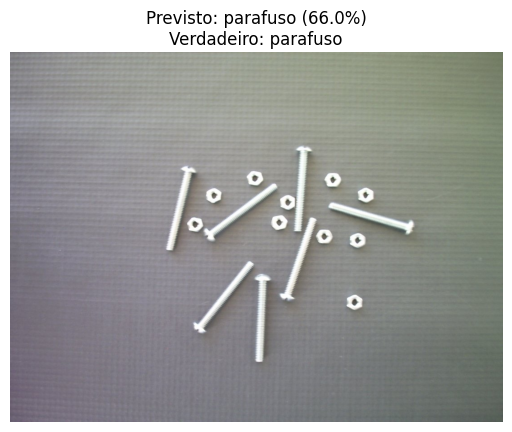


🔍 Resultado:
Classe prevista: parafuso
Confiança: 66.03%
Classe verdadeira: parafuso


In [6]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Seleciona uma amostra aleatória do dataset de teste
sample_idx = random.randint(0, len(test_data) - 1)
img_path, true_label = test_data.dataset.samples[test_data.indices[sample_idx]]
img = Image.open(img_path).convert("RGB")

# Prepara imagem para previsão
x = transform(img).unsqueeze(0).to(device)
with torch.no_grad():
    outputs = model(x)
    probs = torch.nn.functional.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs).item()
    confidence = probs[0][pred_idx].item()

pred_label = class_names[pred_idx]
true_label_name = class_names[true_label]

# Exibe a imagem e o resultado
plt.imshow(img)
plt.axis("off")
plt.title(f"Previsto: {pred_label} ({confidence*100:.1f}%)\nVerdadeiro: {true_label_name}")
plt.show()

print(f"\n🔍 Resultado:")
print(f"Classe prevista: {pred_label}")
print(f"Confiança: {confidence*100:.2f}%")
print(f"Classe verdadeira: {true_label_name}")

# 🧾 Relatório Técnico Automático — Agente de Visão (CNN)
Gera um relatório em formato textual e JSON compatível com o AI Agent Hub.

📋 Conteúdo:
- Nome do modelo e arquitetura
- Acurácia final
- Classes detectadas
- Status técnico (Aprovado / Monitorar / Revisar)
- Observações e recomendações automáticas
- Log JSON salvo em /content/data/logs/


In [7]:
import json
from datetime import datetime
import uuid
import os

def gerar_relatorio_tecnico_vision(accuracy: float, class_names: list):
    """Gera relatório técnico em formato textual e JSON padronizado."""

    # Define status com base na acurácia
    if accuracy >= 0.90:
        status = "Aprovado"
        observacao = "O modelo apresenta desempenho excelente, com alta precisão na classificação entre porcas e parafusos."
        recomendacao = "Pode ser utilizado em ambiente produtivo com monitoramento periódico."
    elif 0.75 <= accuracy < 0.90:
        status = "Monitorar"
        observacao = "O modelo demonstra bom desempenho, porém com pequenas variações entre classes."
        recomendacao = "Recomenda-se coletar mais amostras para reduzir discrepâncias."
    else:
        status = "Revisar"
        observacao = "O modelo apresenta acurácia insuficiente para uso confiável."
        recomendacao = "É necessário revisar o dataset e realizar novo treinamento."

    # Monta texto técnico formatado
    report_text = (
        f"Relatório Técnico — Agente de Visão (CNN)\n"
        f"{'-'*55}\n"
        f"📅 Data UTC: {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')}\n"
        f"🧠 Modelo: MobileNetV2 (PyTorch, CPU)\n"
        f"🏷️ Classes: {', '.join(class_names)}\n"
        f"🎯 Acurácia final: {accuracy*100:.2f}%\n"
        f"📊 Status técnico: {status}\n"
        f"\n📋 Observação:\n{observacao}\n"
        f"\n💡 Recomendações:\n{recomendacao}\n"
        f"{'-'*55}\n"
    )

    # Estrutura JSON para integração no hub
    output = {
        "agent": "vision_agent_cnn",
        "model": "MobileNetV2",
        "framework": "PyTorch",
        "accuracy": round(accuracy, 3),
        "classes": class_names,
        "status": status,
        "observacao": observacao,
        "recomendacao": recomendacao,
        "report_text": report_text,
        "timestamp_utc": datetime.utcnow().isoformat() + "Z"
    }

    # Salva log JSON no mesmo padrão dos outros agentes
    log_path = f"/content/data/logs/vision_agent_cnn_report_{uuid.uuid4().hex[:8]}.json"
    os.makedirs(os.path.dirname(log_path), exist_ok=True)
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(output, f, ensure_ascii=False, indent=2)

    print(report_text)
    print(f"🧾 Log técnico salvo em: {log_path}")

    return output, log_path


# ▶️ Gera o relatório técnico com base nos resultados do treino
relatorio, log_path = gerar_relatorio_tecnico_vision(accuracy, class_names)

Relatório Técnico — Agente de Visão (CNN)
-------------------------------------------------------
📅 Data UTC: 2025-11-12 19:22:48
🧠 Modelo: MobileNetV2 (PyTorch, CPU)
🏷️ Classes: parafuso, porca
🎯 Acurácia final: 66.67%
📊 Status técnico: Revisar

📋 Observação:
O modelo apresenta acurácia insuficiente para uso confiável.

💡 Recomendações:
É necessário revisar o dataset e realizar novo treinamento.
-------------------------------------------------------

🧾 Log técnico salvo em: /content/data/logs/vision_agent_cnn_report_526ff8ba.json


/tmp/ipython-input-3854740960.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"📅 Data UTC: {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')}\n"
/tmp/ipython-input-3854740960.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z"
